In [6]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2
import matplotlib.pyplot as plt

In [4]:
#load data
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

100%|██████████| 26.4M/26.4M [00:03<00:00, 8.03MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 128kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.42MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 16.5MB/s]


In [5]:
batch_size = 64
#create dataloaders
train_dataloaders = DataLoader(training_data, batch_size=batch_size)
test_dataloaders = DataLoader(test_data, batch_size=batch_size)

for x, y in test_dataloaders:
    print(f"Shape of x [N, C, H, W]: {x.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of x [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


Iterating and visualization the dataset


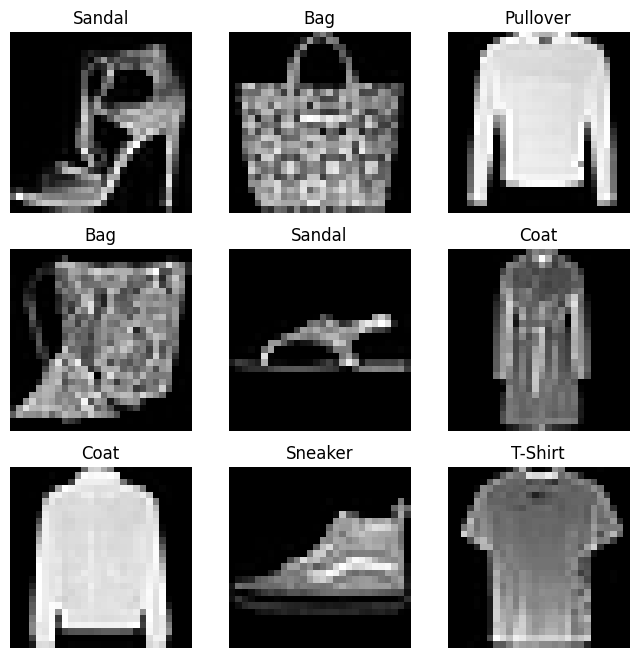

In [7]:
labels_map ={
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8,8))
cols, rows = 3,3
for i in range(1, cols * rows + 1):
  sample_idx = torch.randint(len(training_data), size=(1,)).item()
  img, label = training_data[sample_idx]
  figure.add_subplot(rows, cols, i)
  plt.title(labels_map[label])
  plt.axis("off")
  plt.imshow(img.squeeze(), cmap="gray")
plt.show()

Create a Custom Dataset


In [8]:
from torch.utils.data.dataset import Dataset
import os
import pandas as pd
from torchvision.io import decode_image

class customImageDataset(Dataset):
  def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
    self.img_labels = pd.read_csv(annotations_file)
    self.img_dir = img_dir
    self.transform = transform
    self.target_transform = target_transform

  def __len__(self):
    return len(self.img_labels)

  def __getitem__(self, idx):
    img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
    image = decode_image(img_path)
    label = self.img_labels.iloc[idx, 1]
    if self.transform:
      image = self.transform(image)
    if self.target_transform:
      label = self.target_transform(label)
    return image, label

In [10]:
from torch.utils.data import DataLoader
training_data = DataLoader(training_data, batch_size=64, shuffle=True)
test_data = DataLoader(test_data, batch_size=64, shuffle=True)

Iterate Through the DataLoader


Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


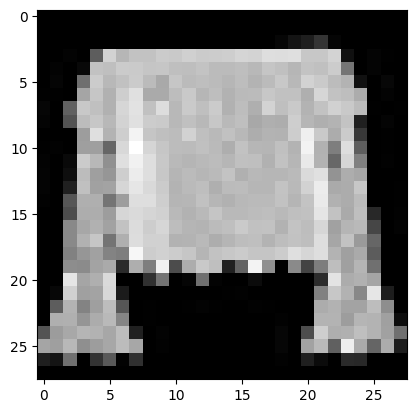

Label: 6


In [11]:
#Display image and label
train_features, train_labels = next(iter(training_data))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")
